### Import the modules

In [20]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

### Data gathering

In [57]:
#Henry Hub Natural Gas
df_ng = yf.download("NG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Copper
df_cu = yf.download("HG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Brent
df_bz = yf.download("BZ=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Corn
df_zc = yf.download("ZC=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Crude Oil WTI
df_cl = yf.download("CL=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cattle-Live
df_le = yf.download("LE=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cocoa
df_cc = yf.download("CC=F", start="2016-01-01", end="2026-08-31", interval="1d")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Data preprocessing

In [67]:
# Reset index and rename columns 
try:
    for df in [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]:
        df.dropna(inplace=True)
        df.reset_index(inplace=True, names = 'Date')
        df.columns = ['Date','Close', 'High', 'Low', 'Open', 'Volume']
        df['Percentage_Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df.drop(['Close', 'High', 'Low', 'Open'], axis=1, inplace=True)
        df.drop(df.index[0], inplace=True)
except Exception as e:
    print(f"An error occurred: {e}")
    pass

/Users/anandjoy/Documents/projects/Ian/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [68]:
def aligning_dataframes(*dfs):
    for df in dfs:
        df["Date"] = pd.to_datetime(df["Date"])

    start_date = max(df["Date"].min() for df in dfs)
    end_date = min(df["Date"].max() for df in dfs)

    return [
        df[df["Date"].between(start_date, end_date)].copy()
        for df in dfs
    ]

def change_dateFormat(df):
    df['Date'] = pd.to_datetime(df['Date'],errors ='coerce').dt.strftime('%Y-%m-%d')
    


print(f'Size before algnment: {df_cl.shape, df_cu.shape, df_bz.shape, df_zc.shape, df_le.shape, df_cc.shape , df_ng.shape}')

df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc = aligning_dataframes(df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc)

print(f'Size after algnment: {df_cl.shape, df_cu.shape, df_bz.shape, df_zc.shape, df_le.shape, df_cc.shape , df_ng.shape}')


Size before algnment: ((2678, 4), (2678, 4), (2679, 4), (2675, 4), (2677, 4), (2678, 4), (2679, 4))
Size after algnment: ((2678, 4), (2678, 4), (2679, 4), (2675, 4), (2677, 4), (2678, 4), (2679, 4))


In [69]:
(set(df_cl["Date"]) - set(df_cu["Date"])), (set(df_cu["Date"]) - set(df_cl["Date"])), (set(df_cl["Date"]) - set(df_bz["Date"])), (set(df_bz["Date"]) - set(df_cl["Date"]))

({Timestamp('2018-01-29 00:00:00')},
 {Timestamp('2023-11-23 00:00:00')},
 set(),
 {Timestamp('2023-11-23 00:00:00')})

In [105]:
dfs = {
    "NG": df_ng,
    "Copper": df_cu,
    "Brent": df_bz,
    "Corn": df_zc,
    "WTI": df_cl,
    "Cattle": df_le,
    "Cocoa": df_cc
}

all_dates = pd.DatetimeIndex(
    pd.concat([df["Date"] for df in dfs.values()])
).drop_duplicates().sort_values()

for name, df in dfs.items():
    df_dates = pd.DatetimeIndex(df["Date"])
    missing = all_dates.difference(df_dates)
    print(f"{name}: missing dates = {len(missing)}")
    print(missing[:10])

NG: missing dates = 0
DatetimeIndex([], dtype='datetime64[s]', name='Date', freq=None)
Copper: missing dates = 1
DatetimeIndex(['2018-01-29'], dtype='datetime64[s]', name='Date', freq=None)
Brent: missing dates = 0
DatetimeIndex([], dtype='datetime64[s]', name='Date', freq=None)
Corn: missing dates = 4
DatetimeIndex(['2018-12-17', '2018-12-18', '2023-11-23', '2025-07-04'], dtype='datetime64[s]', name='Date', freq=None)
WTI: missing dates = 1
DatetimeIndex(['2023-11-23'], dtype='datetime64[s]', name='Date', freq=None)
Cattle: missing dates = 2
DatetimeIndex(['2023-11-23', '2025-07-04'], dtype='datetime64[s]', name='Date', freq=None)
Cocoa: missing dates = 1
DatetimeIndex(['2023-11-23'], dtype='datetime64[s]', name='Date', freq=None)


In [99]:
dfs = {
    "Natural Gas": df_ng,
    "Copper": df_cu,
    "Brent": df_bz,
    "Corn": df_zc,
    "Crude Oil WTI": df_cl,
    "Cattle-Live": df_le,
    "Cocoa": df_cc
}

all_dates = set.intersection(*(set(df["Date"]) for df in dfs.values()))

In [104]:
m = *(set(df["Date"]) for df in dfs.values())

m

SyntaxError: can't use starred expression here (2298351014.py, line 1)

In [103]:
for _m in m:
    print(_m)

{Timestamp('2022-04-26 00:00:00'), Timestamp('2016-07-13 00:00:00'), Timestamp('2016-04-05 00:00:00'), Timestamp('2025-12-30 00:00:00'), Timestamp('2017-05-11 00:00:00'), Timestamp('2023-01-12 00:00:00'), Timestamp('2016-02-24 00:00:00'), Timestamp('2016-12-05 00:00:00'), Timestamp('2025-02-12 00:00:00'), Timestamp('2022-06-28 00:00:00'), Timestamp('2022-12-30 00:00:00'), Timestamp('2021-10-18 00:00:00'), Timestamp('2023-12-07 00:00:00'), Timestamp('2018-02-07 00:00:00'), Timestamp('2017-07-11 00:00:00'), Timestamp('2023-10-31 00:00:00'), Timestamp('2017-04-24 00:00:00'), Timestamp('2021-10-14 00:00:00'), Timestamp('2017-04-20 00:00:00'), Timestamp('2022-10-03 00:00:00'), Timestamp('2018-08-06 00:00:00'), Timestamp('2020-06-01 00:00:00'), Timestamp('2022-11-14 00:00:00'), Timestamp('2020-12-01 00:00:00'), Timestamp('2018-12-06 00:00:00'), Timestamp('2016-07-22 00:00:00'), Timestamp('2023-02-06 00:00:00'), Timestamp('2018-11-26 00:00:00'), Timestamp('2026-04-09 00:00:00'), Timestamp('20

### Log returns

In [ ]:
try:
    for df in [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]:
        df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
        df['Percentage_Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df.drop(['Close', 'High', 'Low', 'Open'], axis=1, inplace=True)
        df.drop(df.index[0], inplace=True)
except Exception as e:
    pass

/Users/anandjoy/Documents/projects/Ian/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Data cleaning

<Axes: xlabel='Date'>

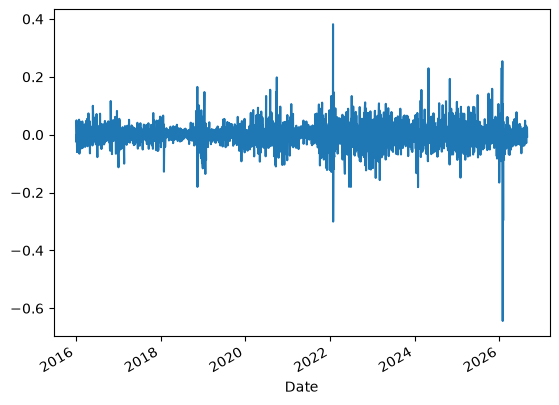

In [ ]:
df_ng['Log_Returns'].plot()

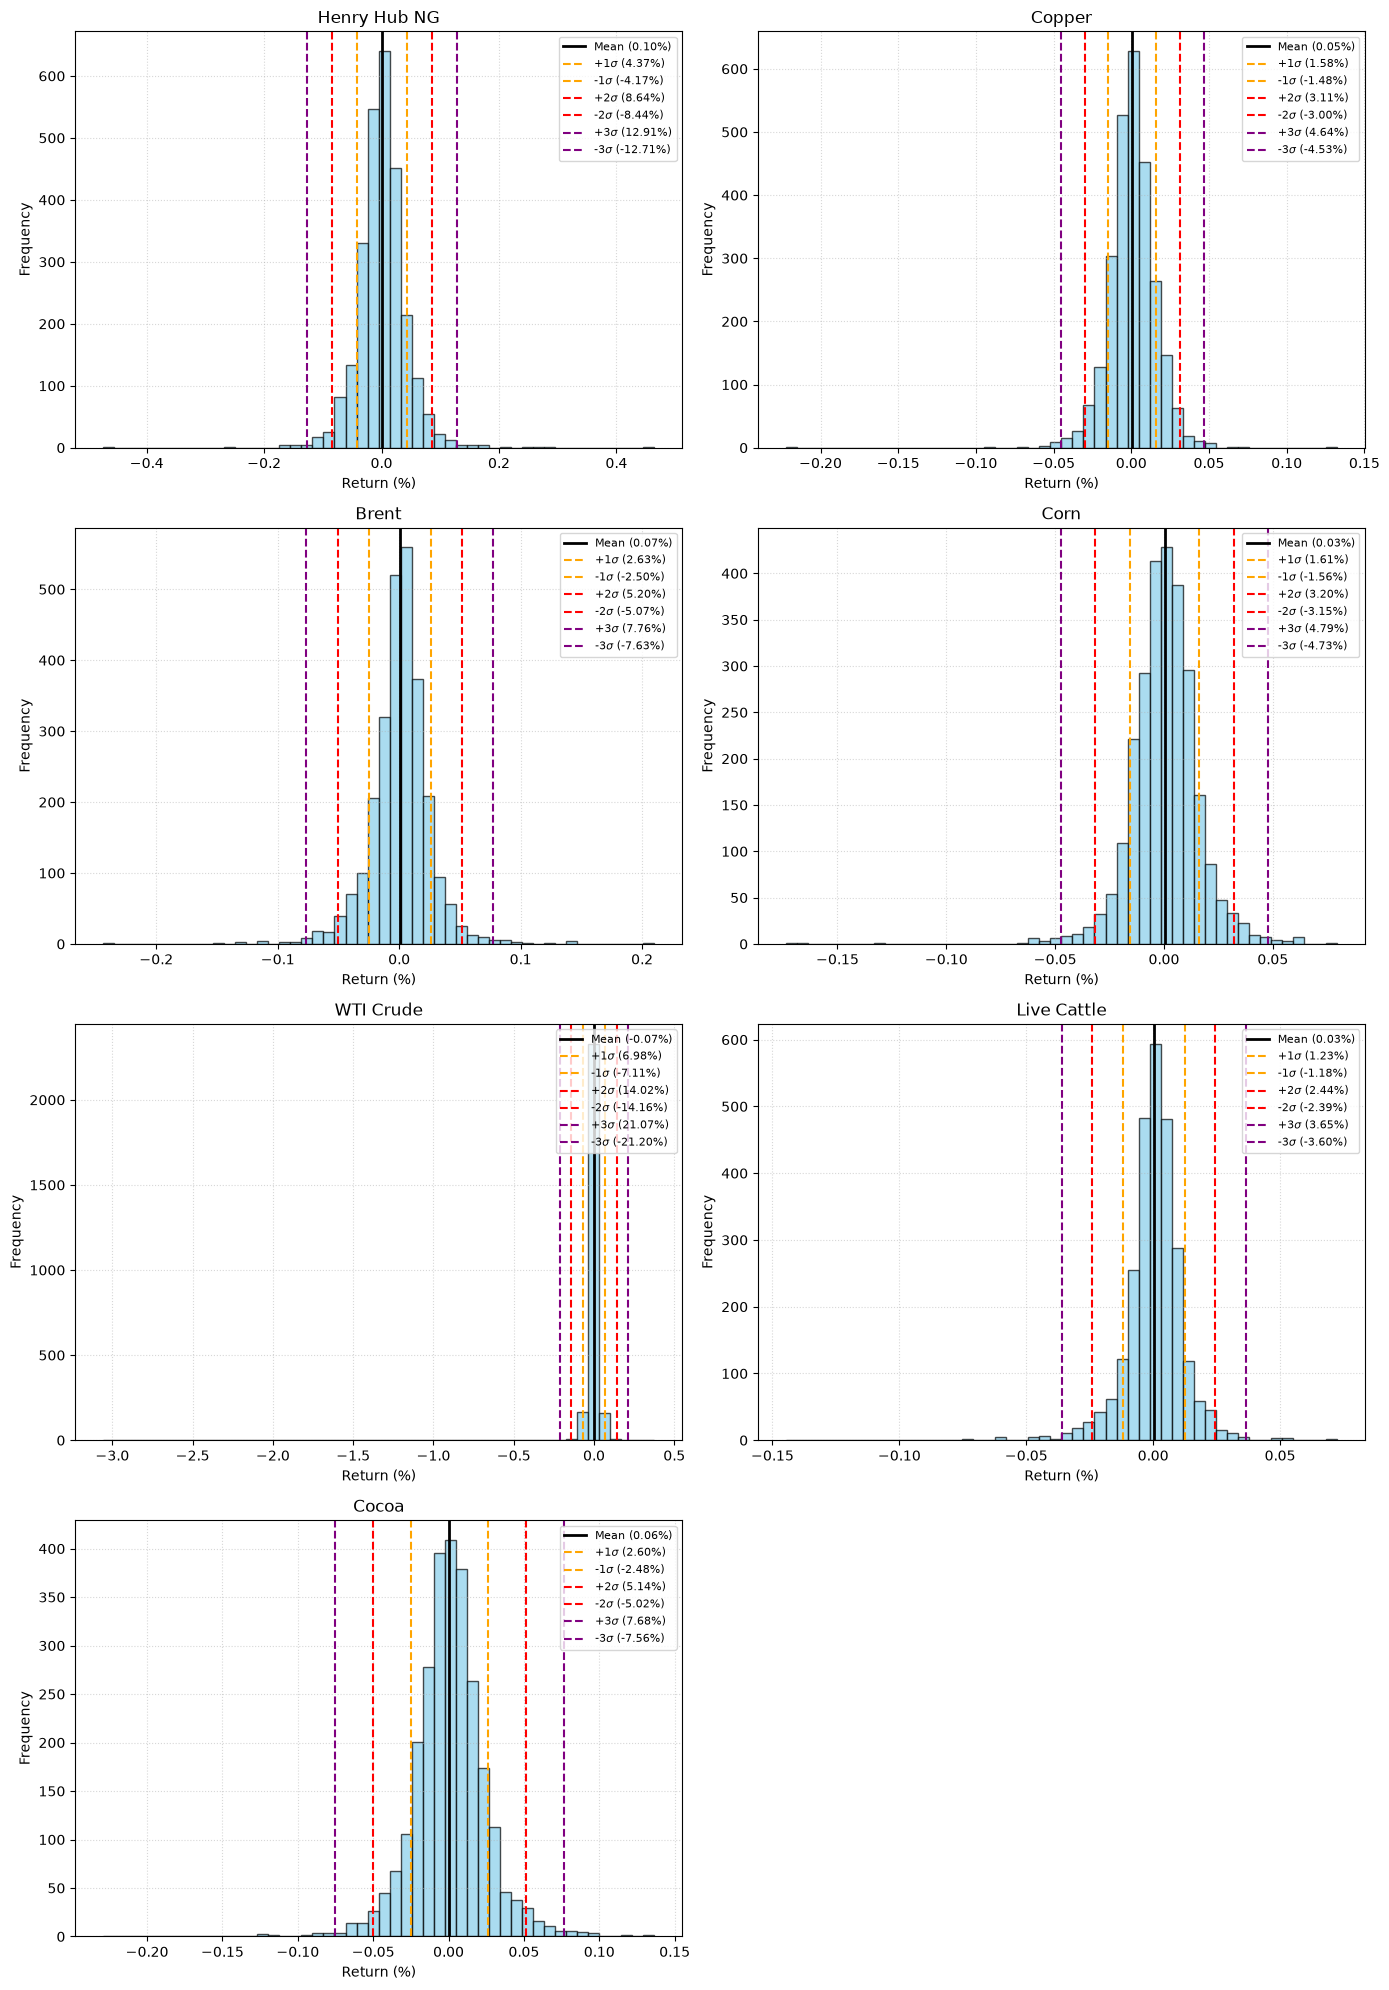

In [6]:
import math

def plot_histogram(s: pd.Series, bins: int = 50, ax=None, title: str = ""):
    s = s.dropna()
    if s.empty:
        return

    mean = s.mean()
    std = s.std(ddof=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    ax.hist(
        s,
        bins=bins,
        edgecolor='black',
        alpha=0.7,
        color='skyblue',
    )

    ax.axvline(
        mean,
        color='black',
        linestyle='-',
        linewidth=2,
        label=f'Mean ({mean * 100:.2f}%)',
    )

    sigma_colors = {1: 'orange', 2: 'red', 3: 'purple'}
    for i, color in sigma_colors.items():
        pos_val = mean + i * std
        neg_val = mean - i * std
        ax.axvline(
            pos_val,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f'+{i}$\\sigma$ ({pos_val * 100:.2f}%)',
        )
        ax.axvline(
            neg_val,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f'-{i}$\\sigma$ ({neg_val * 100:.2f}%)',
        )

    ax.set_title(title or 'Histogram of Returns')
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Frequency')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)

    return ax


commodity_series = {
    'Henry Hub NG': df_ng['Percentage_Returns'],
    'Copper': df_cu['Percentage_Returns'],
    'Brent': df_bz['Percentage_Returns'],
    'Corn': df_zc['Percentage_Returns'],
    'WTI Crude': df_cl['Percentage_Returns'],
    'Live Cattle': df_le['Percentage_Returns'],
    'Cocoa': df_cc['Percentage_Returns'],
}

ncols = 2
nrows = math.ceil(len(commodity_series) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.ravel(axes)

for ax, (name, s) in zip(axes, commodity_series.items()):
    plot_histogram(s, bins=50, ax=ax, title=name)

for ax in axes[len(commodity_series):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

commodity_series = {
    'Henry Hub NG': df_ng['Percentage_Returns'].dropna(),
    'Copper': df_cu['Percentage_Returns'].dropna(),
    'Brent': df_bz['Percentage_Returns'].dropna(),
    'Corn': df_zc['Percentage_Returns'].dropna(),
    'WTI Crude': df_cl['Percentage_Returns'].dropna(),
    'Live Cattle': df_le['Percentage_Returns'].dropna(),
    'Cocoa': df_cc['Percentage_Returns'].dropna(),
}

ncols = 2
nrows = (len(commodity_series) + 1) // ncols

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    subplot_titles=list(commodity_series.keys()),
    horizontal_spacing=0.12,
    vertical_spacing=0.18,
)

for idx, (name, s) in enumerate(commodity_series.items()):
    row = idx // ncols + 1
    col = idx % ncols + 1

    mean = s.mean()
    std = s.std(ddof=1)

    fig.add_trace(
        go.Histogram(
            x=s,
            nbinsx=100,
            opacity=0.7,
            name=name,
            marker_color='skyblue',
            showlegend=False
        ),
        row=row, col=col
    )

    fig.add_vline(
        x=mean,
        line_color='black',
        line_width=2,
        line_dash='solid',
        annotation_text=f"Mean: {mean * 100:.2f}%",
        annotation_position="top left",
        row=row, col=col
    )

    for i, color in {1: 'orange', 2: 'red', 3: 'purple'}.items():
        fig.add_vline(
            x=mean + i * std,
            line_color=color,
            line_width=1.5,
            line_dash='dash',
            row=row, col=col
        )
        fig.add_vline(
            x=mean - i * std,
            line_color=color,
            line_width=1.5,
            line_dash='dash',
            row=row, col=col
        )

fig.update_layout(
    title="Commodity Return Histograms",
    template="plotly_white",
    height=900,
    width=1400,
    showlegend=False
)

fig.update_xaxes(title_text="Return (%)")
fig.update_yaxes(title_text="Frequency")

fig.show()

In [ ]:
for idx, (name, s) in enumerate(commodity_series.items()):
    print(f"s : {s} {name}: Mean = {s.mean() * 100:.4f}%, Std Dev = {s.std(ddof=1) * 100:.4f}%")    


    

s : Date
2016-01-05   -0.003864
2016-01-06   -0.025263
2016-01-07    0.049483
2016-01-08    0.037087
2016-01-11   -0.031227
                ...   
2026-08-24    0.003240
2026-08-25   -0.004323
2026-08-26    0.025661
2026-08-27    0.022614
2026-08-28   -0.006557
Name: Log_Returns, Length: 2679, dtype: float64 Henry Hub NG: Mean = 0.0080%, Std Dev = 4.3087%
s : Date
2016-01-05    0.008656
2016-01-06   -0.003838
2016-01-07   -0.031741
2016-01-08    0.000496
2016-01-11   -0.024600
                ...   
2026-08-24    0.002959
2026-08-25    0.016606
2026-08-26   -0.017288
2026-08-27   -0.001138
2026-08-28   -0.003803
Name: Log_Returns, Length: 2678, dtype: float64 Copper: Mean = 0.0431%, Std Dev = 1.5450%
s : Date
2016-01-05   -0.021728
2016-01-06   -0.062016
2016-01-07   -0.014122
2016-01-08   -0.005944
2016-01-11   -0.061463
                ...   
2026-08-24   -0.023800
2026-08-25   -0.039729
2026-08-26   -0.008389
2026-08-27    0.020954
2026-08-28   -0.004357
Name: Log_Returns, Length: 2

In [16]:
commodity_series = {
    'Henry Hub NG': df_ng['Log_Returns'].dropna(),
    'Copper': df_cu['Log_Returns'].dropna(),
    'Brent': df_bz['Log_Returns'].dropna(),
    'Corn': df_zc['Log_Returns'].dropna(),
    'WTI Crude': df_cl['Log_Returns'].dropna(),
    'Live Cattle': df_le['Log_Returns'].dropna(),
    'Cocoa': df_cc['Log_Returns'].dropna(),
}

ncols = 2
nrows = (len(commodity_series) + 1) // ncols

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    subplot_titles=list(commodity_series.keys()),
    horizontal_spacing=0.12,
    vertical_spacing=0.18,
)

for idx, (name, s) in enumerate(commodity_series.items()):
    row = idx // ncols + 1
    col = idx % ncols + 1

    mean = s.mean()
    std = s.std(ddof=1)

    fig.add_trace(
        go.Histogram(
            x=s,
            nbinsx=100,
            opacity=0.7,
            name=name,
            marker_color='skyblue',
            showlegend=False
        ),
        row=row, col=col
    )

    fig.add_vline(
        x=mean,
        line_color='black',
        line_width=2,
        line_dash='solid',
        annotation_text=f"Mean: {mean * 100:.2f}%",
        annotation_position="top left",
        row=row, col=col
    )

    for i, color in {1: 'orange', 2: 'red', 3: 'purple'}.items():
        fig.add_vline(
            x=mean + i * std,
            line_color=color,
            line_width=1.5,
            line_dash='dash',
            row=row, col=col
        )
        fig.add_vline(
            x=mean - i * std,
            line_color=color,
            line_width=1.5,
            line_dash='dash',
            row=row, col=col
        )

fig.update_layout(
    title="Commodity Return Histograms",
    template="plotly_white",
    height=900,
    width=1400,
    showlegend=False
)

fig.update_xaxes(title_text="Return (%)")
fig.update_yaxes(title_text="Frequency")

fig.show()

In [15]:
df_ng.columns

Index(['Volume', 'Percentage_Returns', 'Log_Returns'], dtype='str')